# Transformer Inference: How Inference is Done in Transformers

## 1. Introduction
This guide explains the step-by-step process of **Transformer Inference** (prediction stage). While the training phase often processes sequences in parallel, the inference phase operates differently, particularly in the decoder section.

### Core Concept: Training vs. Inference
- **Encoder Behavior:** Remains the same in both training and inference. It processes the entire input sequence simultaneously to create contextual embeddings.
- **Decoder Behavior:** - **Training:** Non-auto-regressive (processes all output tokens at once using masking).
  - **Inference:** **Auto-regressive**. It generates tokens one by one in multiple time steps, where each predicted token is fed back as input for the next step.


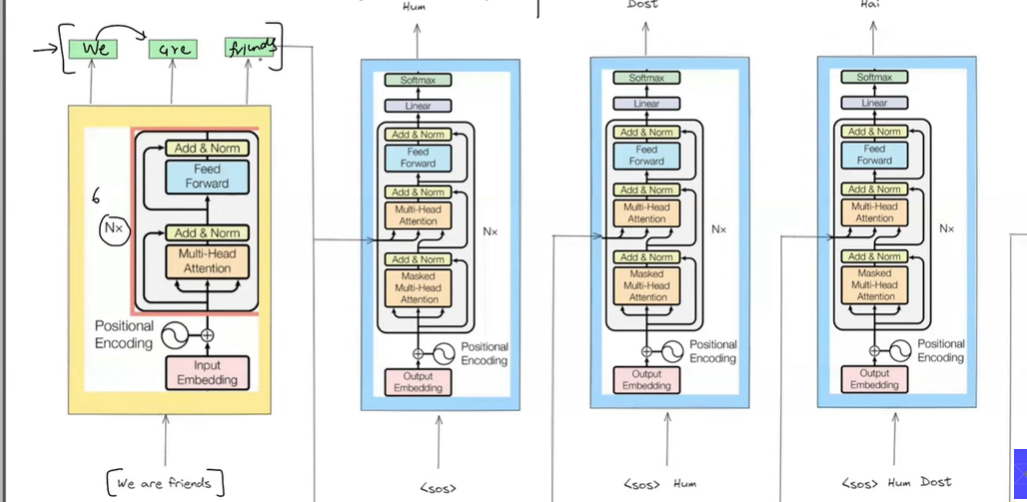

## 2. Setup Example
- **Task:** Machine Translation (English to Hindi).
- **Input Sentence:** "We are friends"
- **Goal:** Predict the Hindi translation "हम दोस्त हैं" (Hum dost hain).

---

## 3. Step-by-Step Inference Process

### Step 1: Encoder Processing
1. **Tokenization:** The input "We are friends" is split into tokens.
2. **Embeddings & Positional Encoding:** Tokens are converted into 512-dimensional vectors, and positional info is added.
3. **Multi-Head Attention & Feed Forward:** The encoder blocks (typically 6) process these vectors to capture context.
4. **Output:** A set of **Contextual Vectors** for each English word. These are sent to the Decoder's Cross-Attention layers.

### Step 2: Decoder Time Step 1 (Generating the First Word)
1. **Start Token:** The process begins by feeding a special `<SOS>` (Start of Sentence) token into the decoder.
2. **Masked Self-Attention:** The `<SOS>` token is processed. Since there's only one token, it only "attends" to itself.
3. **Cross-Attention:** The decoder takes the `<SOS>` vector and compares it with the Encoder's contextual vectors ("We", "are", "friends") to understand which part of the input to focus on.
4. **Linear & Softmax:** The final vector passes through a Linear layer (mapping to vocabulary size) and a Softmax layer to produce probabilities.
5. **Prediction:** The word with the highest probability is selected. 
   - **Result:** "हम" (Hum).

### Step 3: Decoder Time Step 2 (Generating the Second Word)
1. **New Input:** The input is now `[<SOS>, "हम"]`.
2. **Masked Self-Attention:** - **Crucial:** Even during inference, **Masking** is applied. "हम" can see `<SOS>`, but if there were future tokens, it wouldn't. This ensures consistency with how the model was trained.
3. **Cross-Attention:** Both tokens attend to the Encoder's output.
4. **Output Selection:** Although the decoder produces vectors for both tokens, we **only** take the vector corresponding to the last token ("हम") and send it to the final Linear/Softmax layer.
5. **Prediction:** - **Result:** "दोस्त" (Dost).

### Step 4: Subsequent Time Steps
1. **Time Step 3:** Input is `[<SOS>, "हम", "दोस्त"]`. The model predicts "हैं" (Hain).
2. **Time Step 4:** Input is `[<SOS>, "हम", "दोस्त", "हैं"]`.
3. **Termination:** The model predicts the `<EOS>` (End of Sentence) token. Once `<EOS>` is generated, the inference process stops.

---

## 4. Key Takeaways
- **Auto-Regressive Nature:** The decoder must run $N$ times to generate $N$ words.
- **Masking during Inference:** It is maintained to prevent data shift between training and prediction.
- **Context Preservation:** The Encoder output is static throughout the inference process; only the Decoder input grows.

---
*Note: This summary is based on the CampusX Deep Learning series (Day 84).*
